In [17]:
%load_ext autoreload
%autoreload 2
import sys

# instead of creating a package using setup.py or building from a docker/singularity file,
# import the sister directory of src code to be called on in notebook.
# This keeps the notebook free from code to only hold visualizations and is easier to test
# It also helps keep the state of variables clean such that cells aren't run out of order with a mysterious state
sys.path.append("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import xarray as xr
import numpy as np
import pandas as pd
import datetime as dt
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as crs
import geopandas as gpd
import matplotlib.patches as mpatches
import cartopy.feature as cfeature
import matplotlib.image as mpimg

In [19]:
station = "BUFF"

In [20]:
file_path = f"/home/aevans/nwp_bias/src/machine_learning/data/profiler_images/2024/PROF_{station}"
final_ls = []

for m in np.arange(1, 13):  # loop months
    hourly_means = []  # store 24-hour averages for this month

    for h in np.arange(0, 24):  # loop hours
        hour_data = []

        for d in np.arange(1, 32):  # loop days
            file = f"{file_path}/PROF_{station}_2024_{str(m).zfill(2)}{str(d).zfill(2)}{str(h).zfill(2)}.npy"

            if os.path.exists(file):
                data = np.load(file)  # (121, 6, 11)
                avg = data.mean(axis=1, keepdims=True)  # (121, 1, 11)
                # Mask the -999 values
                masked_data = np.ma.masked_equal(data, -999)  # mask all -999

                # Compute mean along axis=1, ignoring masked values
                avg = masked_data.mean(axis=1).filled(
                    np.nan
                )  # shape (121, 11), fill with np.nan if all values are masked

                # Keep dims if needed
                avg = avg[:, np.newaxis, :]  # (121, 1, 11)

                hour_data.append(avg)

        if hour_data:  # only average if data exists
            hour_stack = np.stack(hour_data, axis=0)  # (num_days, 121, 1, 11)
            hour_mean = hour_stack.mean(axis=0)  # (121, 1, 11)
        else:
            hour_mean = np.full((121, 1, 11), np.nan)  # placeholder if no data

        hourly_means.append(hour_mean)

    month_arr = np.stack(hourly_means, axis=0)  # (24, 121, 1, 11)
    final_ls.append(month_arr)

# Final result: shape (12, 24, 121, 1, 11)
final_arr = np.stack(final_ls, axis=0)

print(final_arr.shape)

(12, 24, 121, 1, 11)


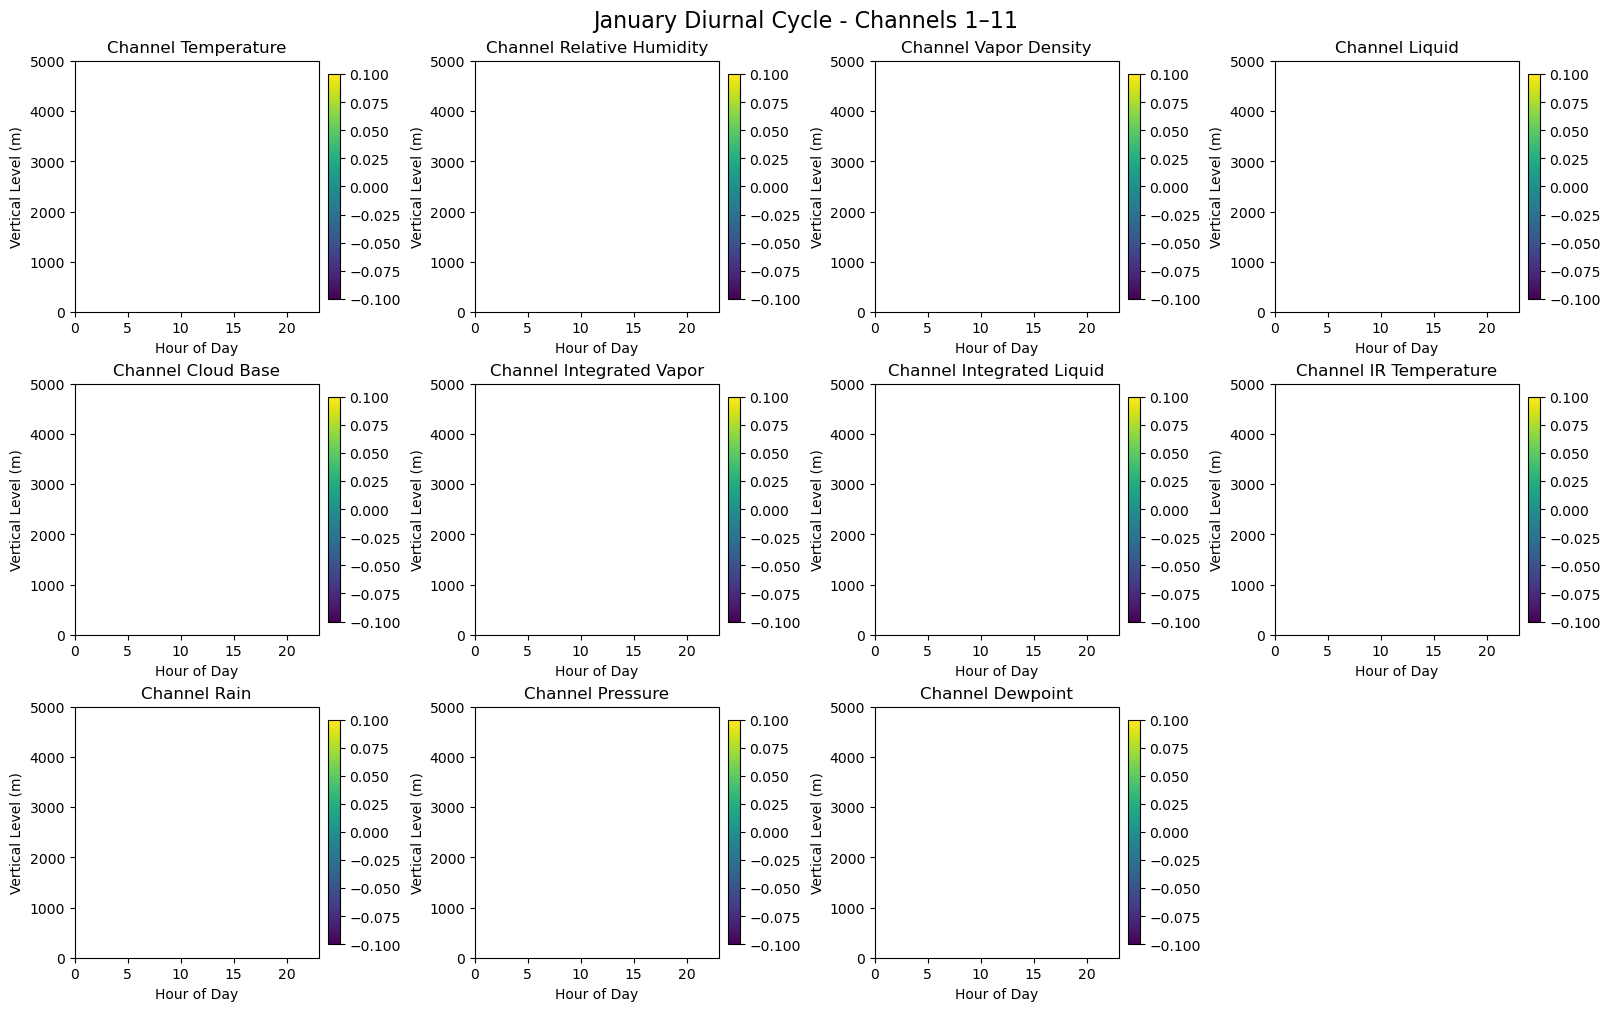

In [21]:
import matplotlib.pyplot as plt
import numpy as np

channels = [
    "Temperature",
    "Relative Humidity",
    "Vapor Density",
    "Liquid",
    "Cloud Base",
    "Integrated Vapor",
    "Integrated Liquid",
    "IR Temperature",
    "Rain",
    "Pressure",
    "Dewpoint",
]

# Extract January
jan = final_arr[0]  # (24, 121, 1, 11)
jan = jan.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = jan.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(jan.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        jan[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if jan.shape[2] < len(axes):
    for i in range(jan.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("January Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

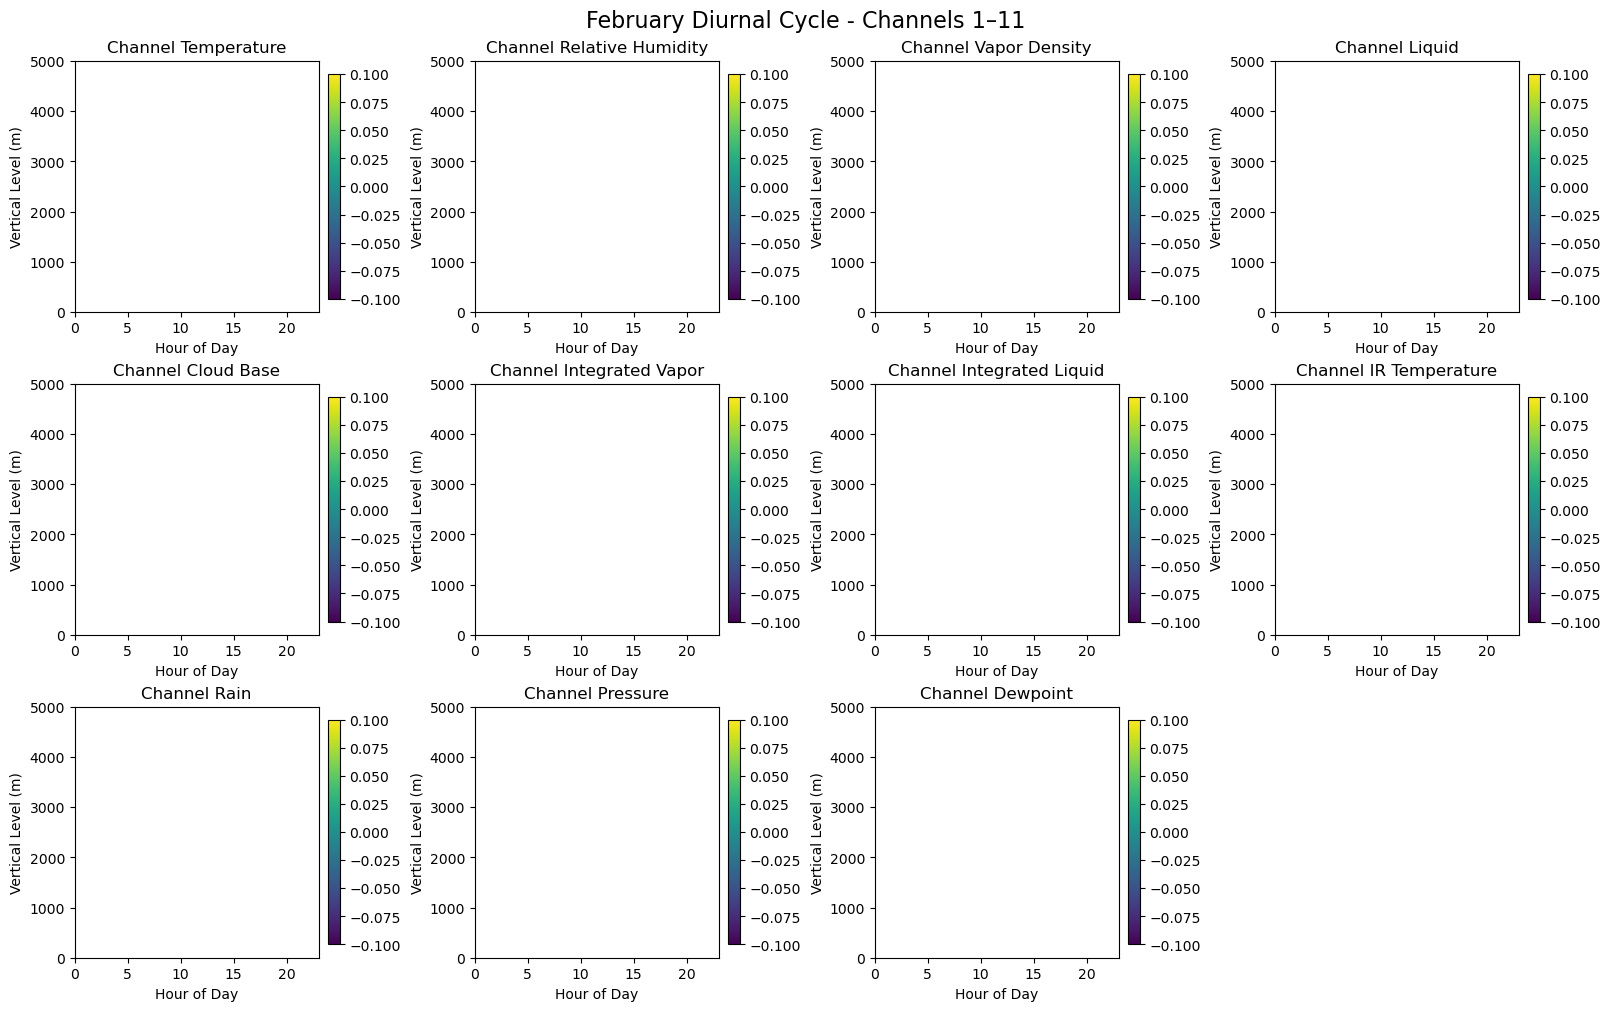

In [22]:
# Extract February
feb = final_arr[1]  # (24, 121, 1, 11)
feb = feb.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = feb.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(feb.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        feb[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if feb.shape[2] < len(axes):
    for i in range(feb.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("February Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

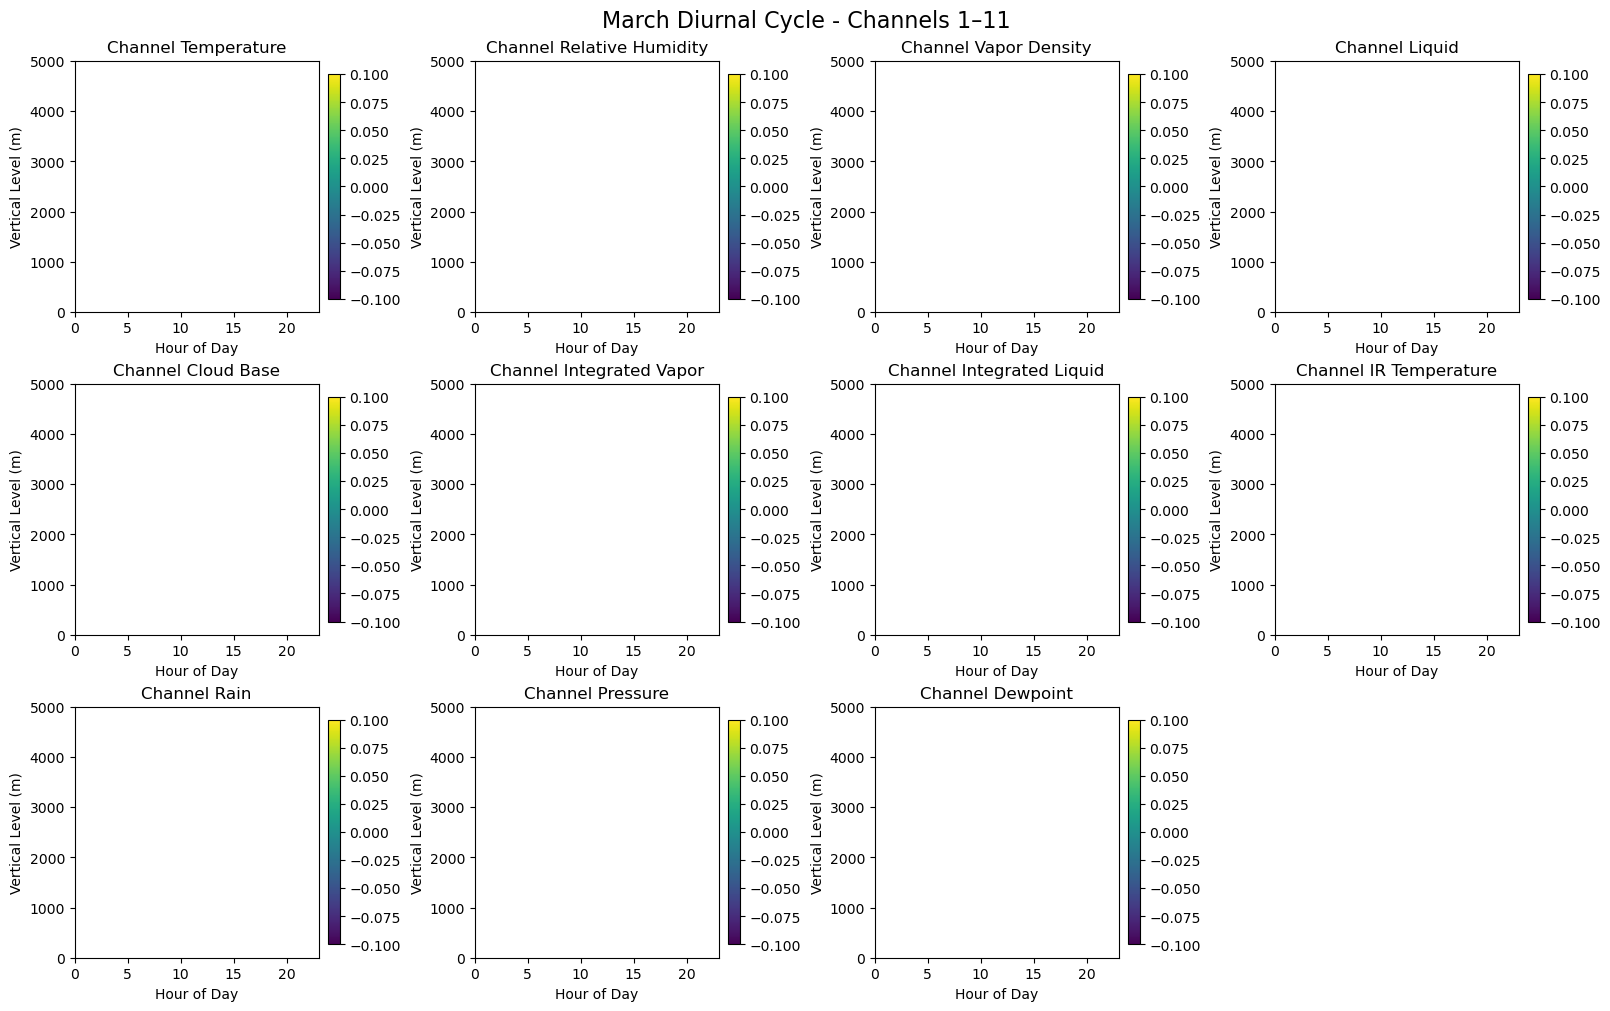

In [23]:
# Extract March
mar = final_arr[2]  # (24, 121, 1, 11)
mar = mar.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = mar.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(mar.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        mar[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if mar.shape[2] < len(axes):
    for i in range(mar.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("March Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

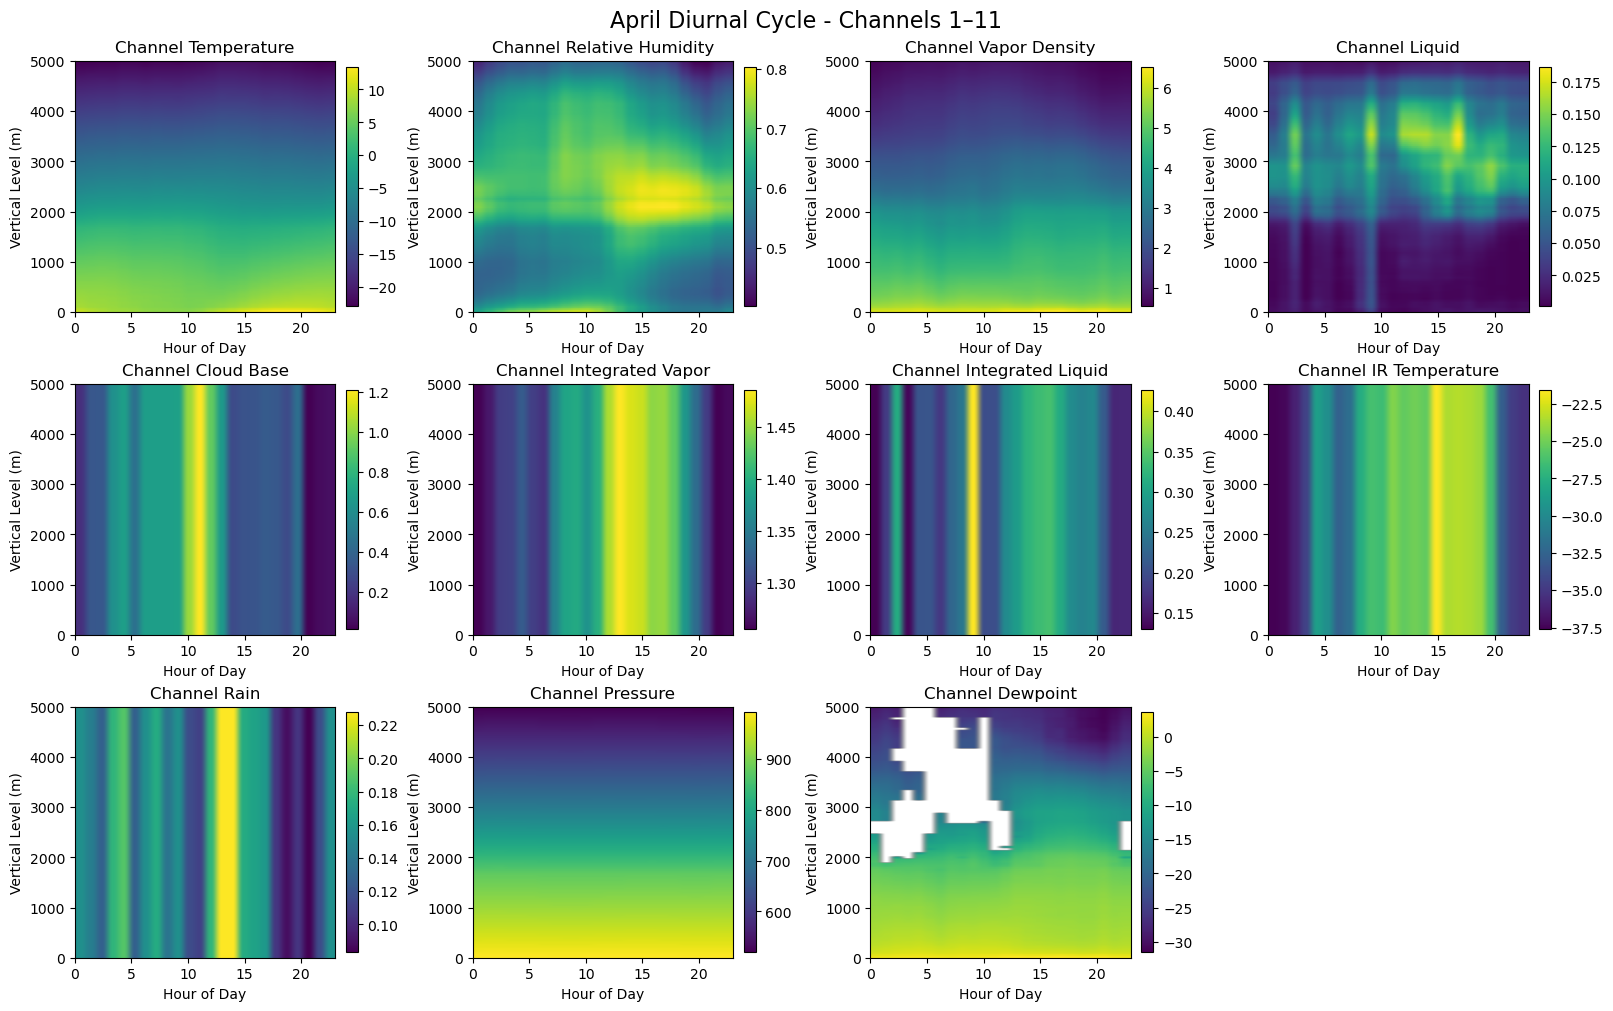

In [ ]:
# Extract April
apr = final_arr[3]  # (24, 121, 1, 11)
apr = apr.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = apr.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(apr.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        apr[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if apr.shape[2] < len(axes):
    for i in range(apr.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("April Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

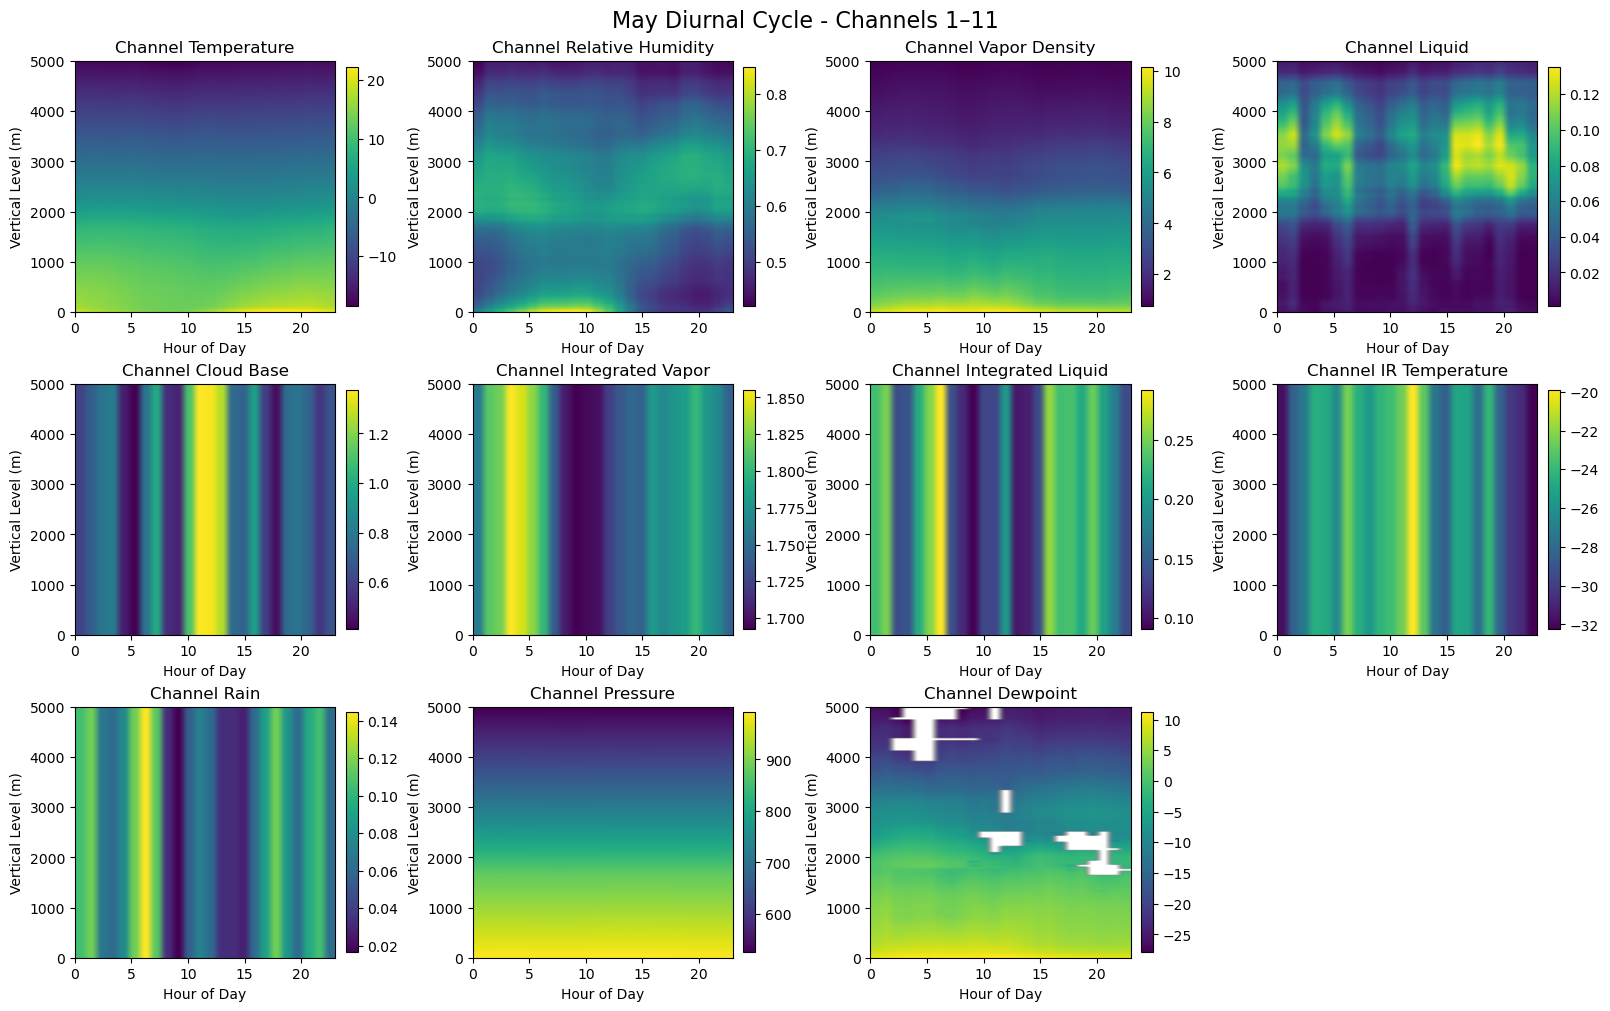

In [ ]:
# Extract May
may = final_arr[4]  # (24, 121, 1, 11)
may = may.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = may.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(may.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        may[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if may.shape[2] < len(axes):
    for i in range(may.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("May Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

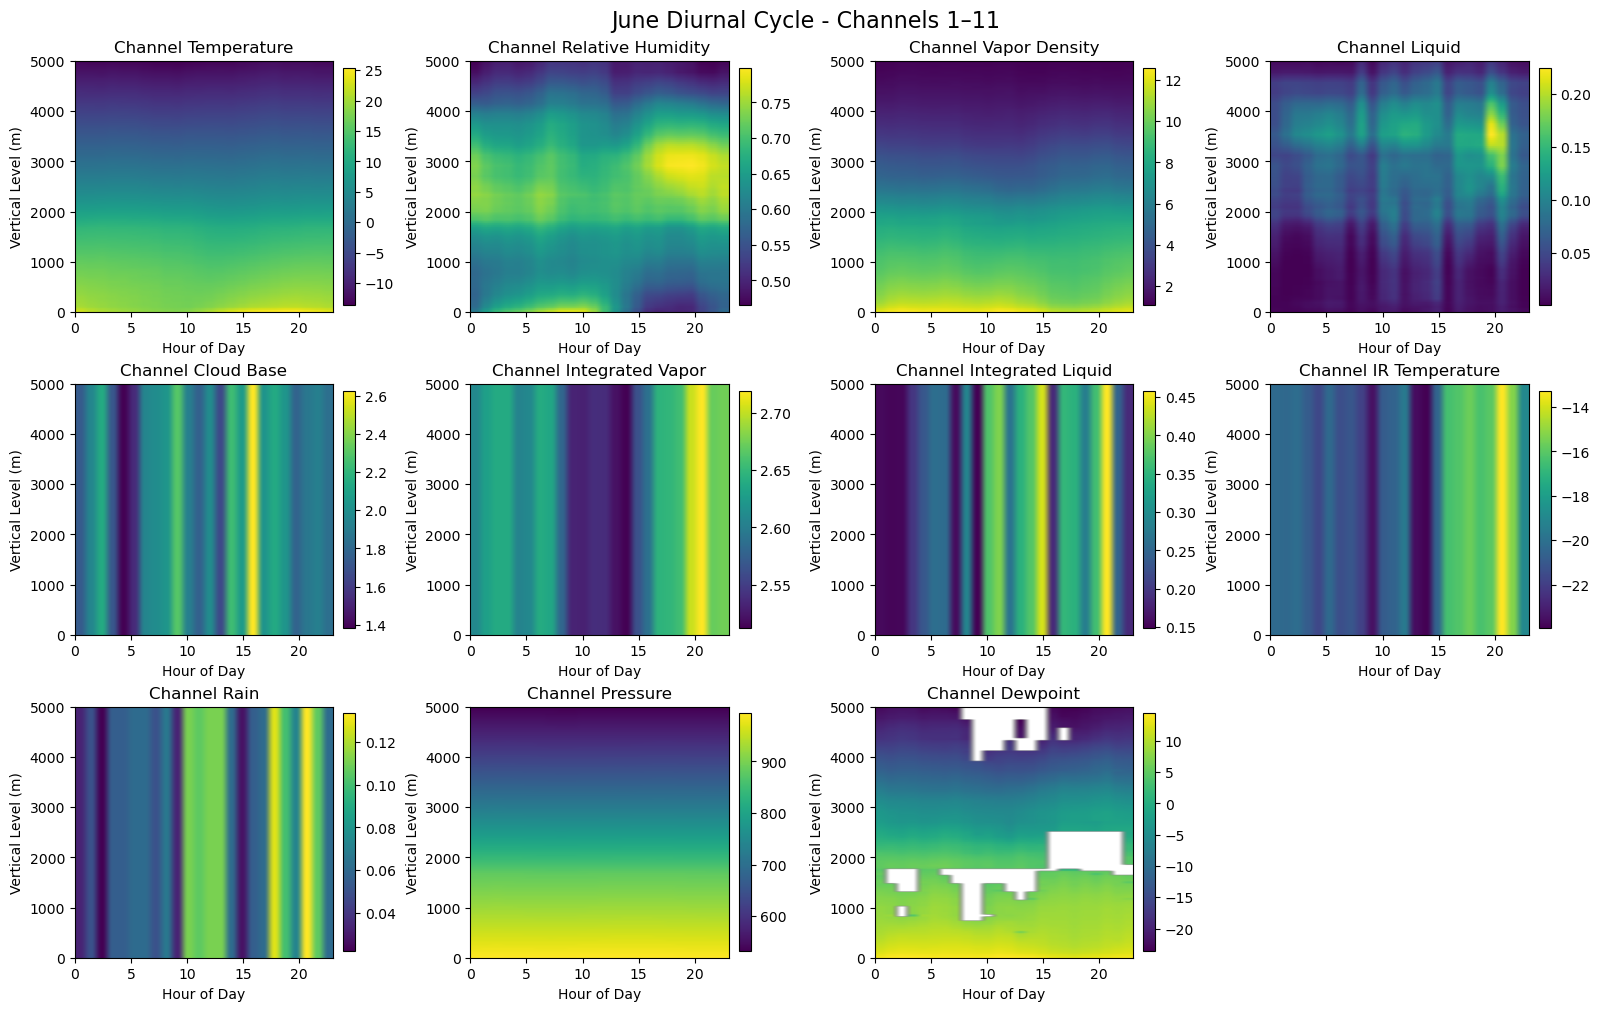

In [ ]:
# Extract June
jun = final_arr[5]  # (24, 121, 1, 11)
jun = jun.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = jun.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(jun.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        jun[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if jun.shape[2] < len(axes):
    for i in range(jun.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("June Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

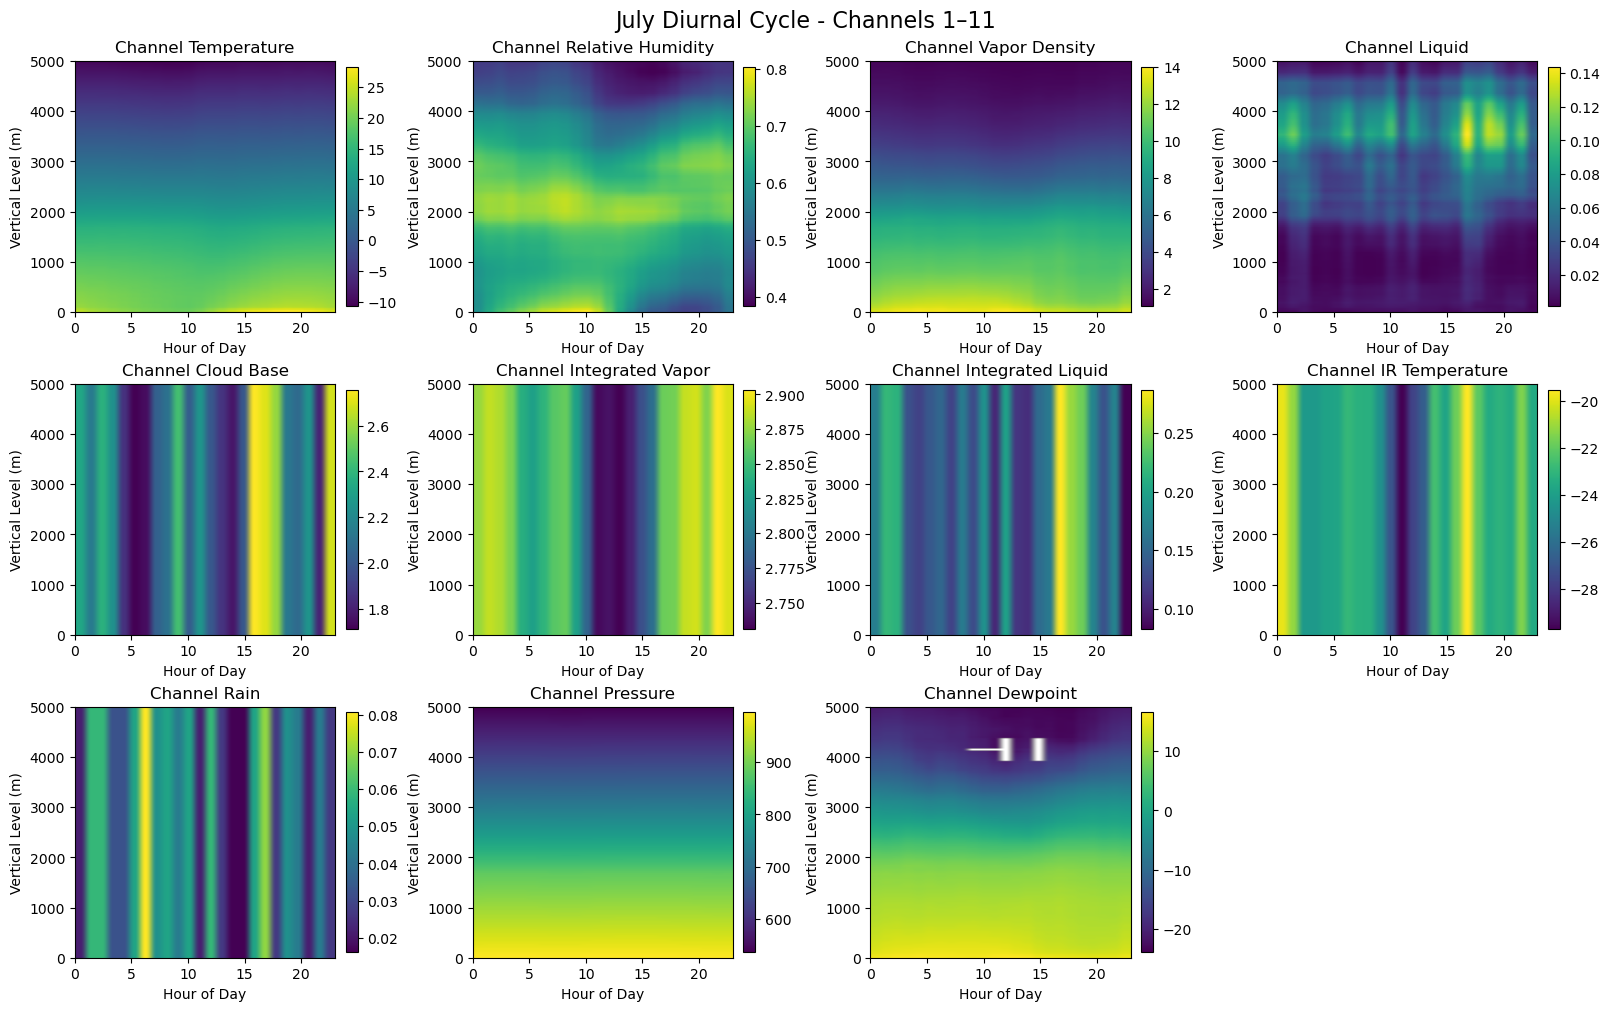

In [ ]:
# Extract July
jul = final_arr[6]  # (24, 121, 1, 11)
jul = jul.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = jul.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(jul.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        jul[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if jul.shape[2] < len(axes):
    for i in range(jul.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("July Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

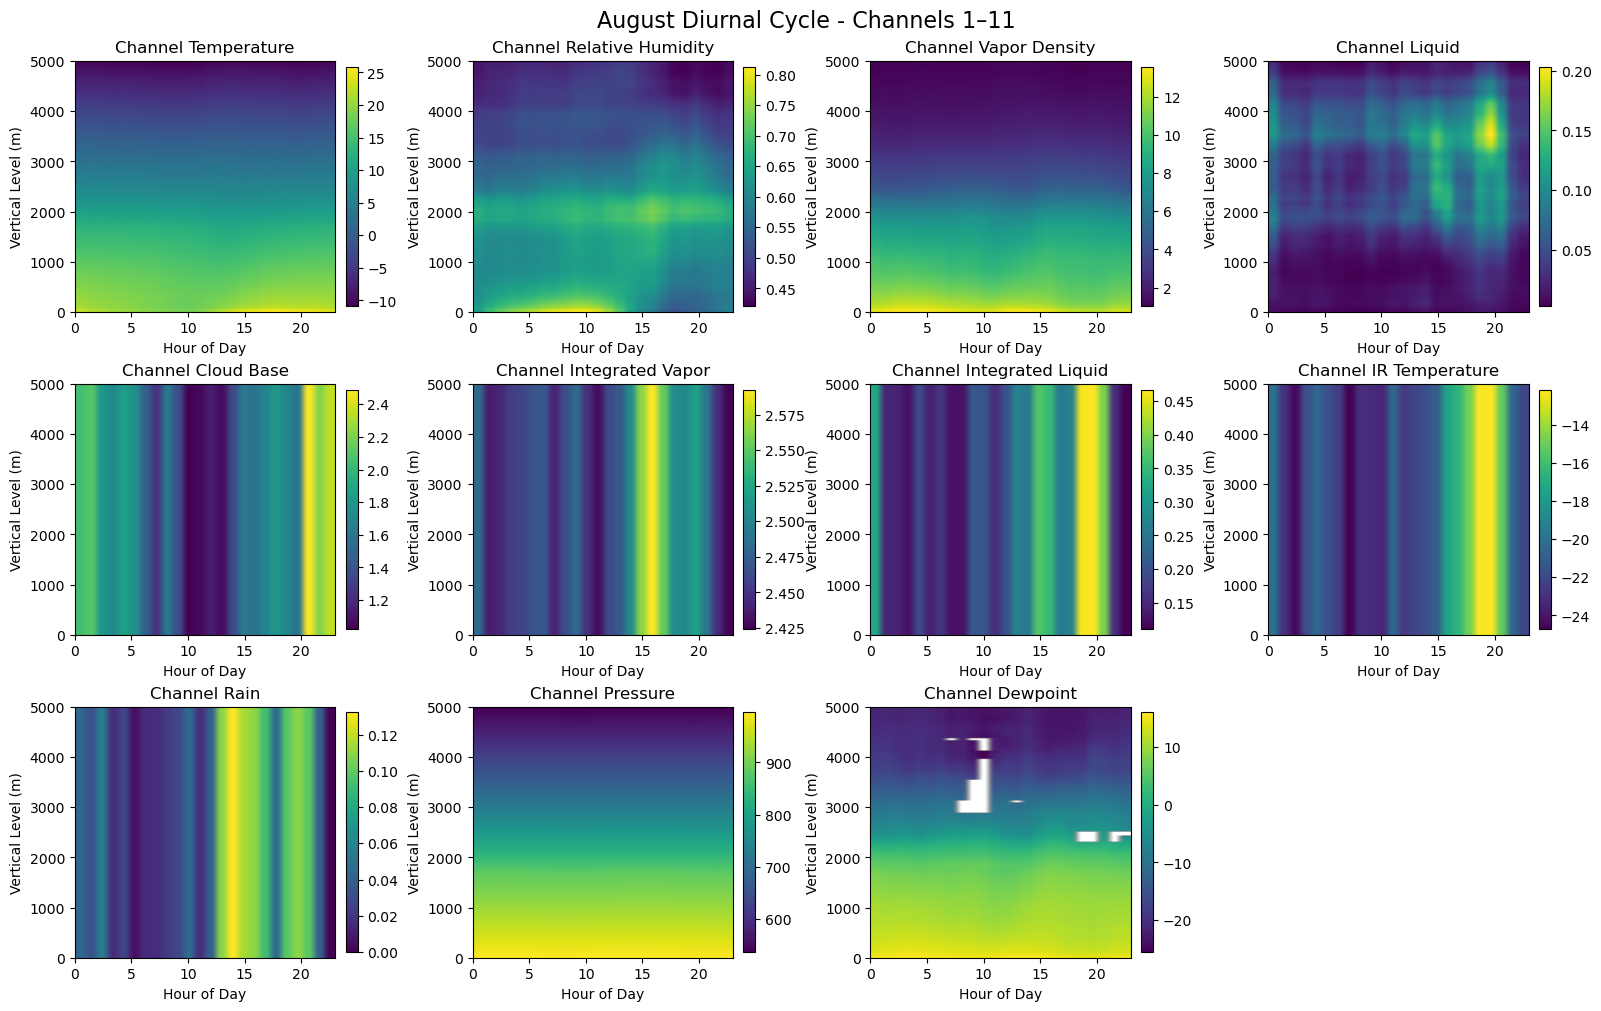

In [ ]:
# Extract August
aug = final_arr[7]  # (24, 121, 1, 11)
aug = aug.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = aug.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(aug.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        aug[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if aug.shape[2] < len(axes):
    for i in range(aug.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("August Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

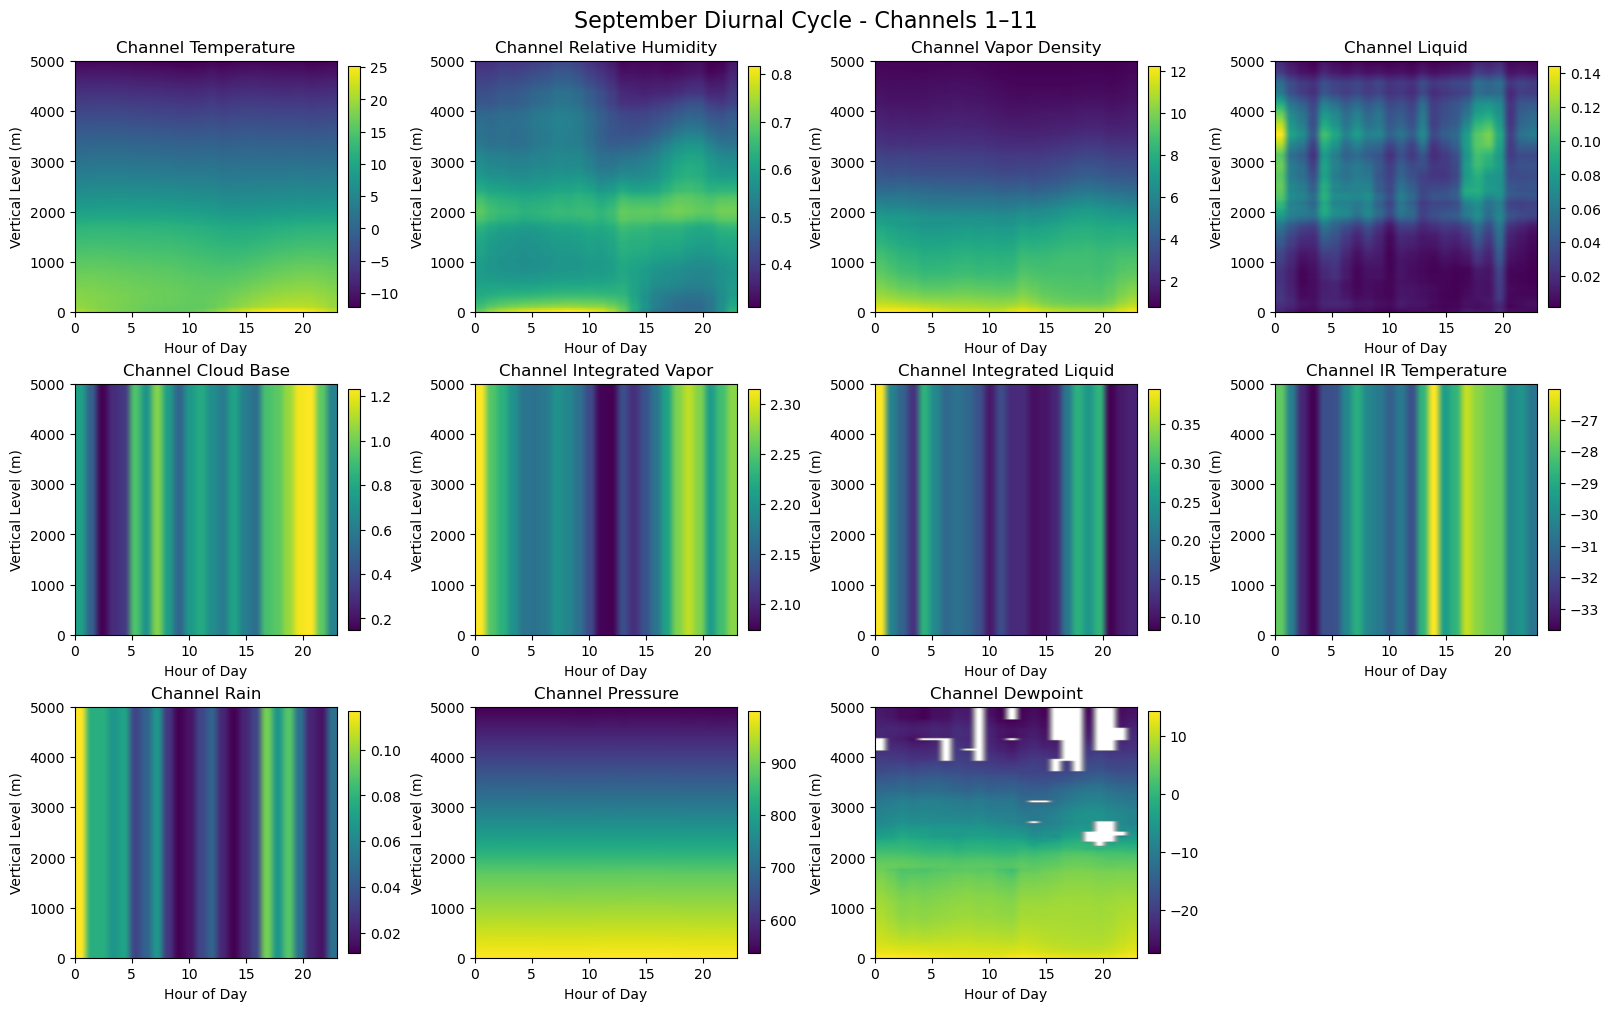

In [ ]:
# Extract September
sep = final_arr[8]  # (24, 121, 1, 11)
sep = sep.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = sep.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(sep.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        sep[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if sep.shape[2] < len(axes):
    for i in range(sep.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("September Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

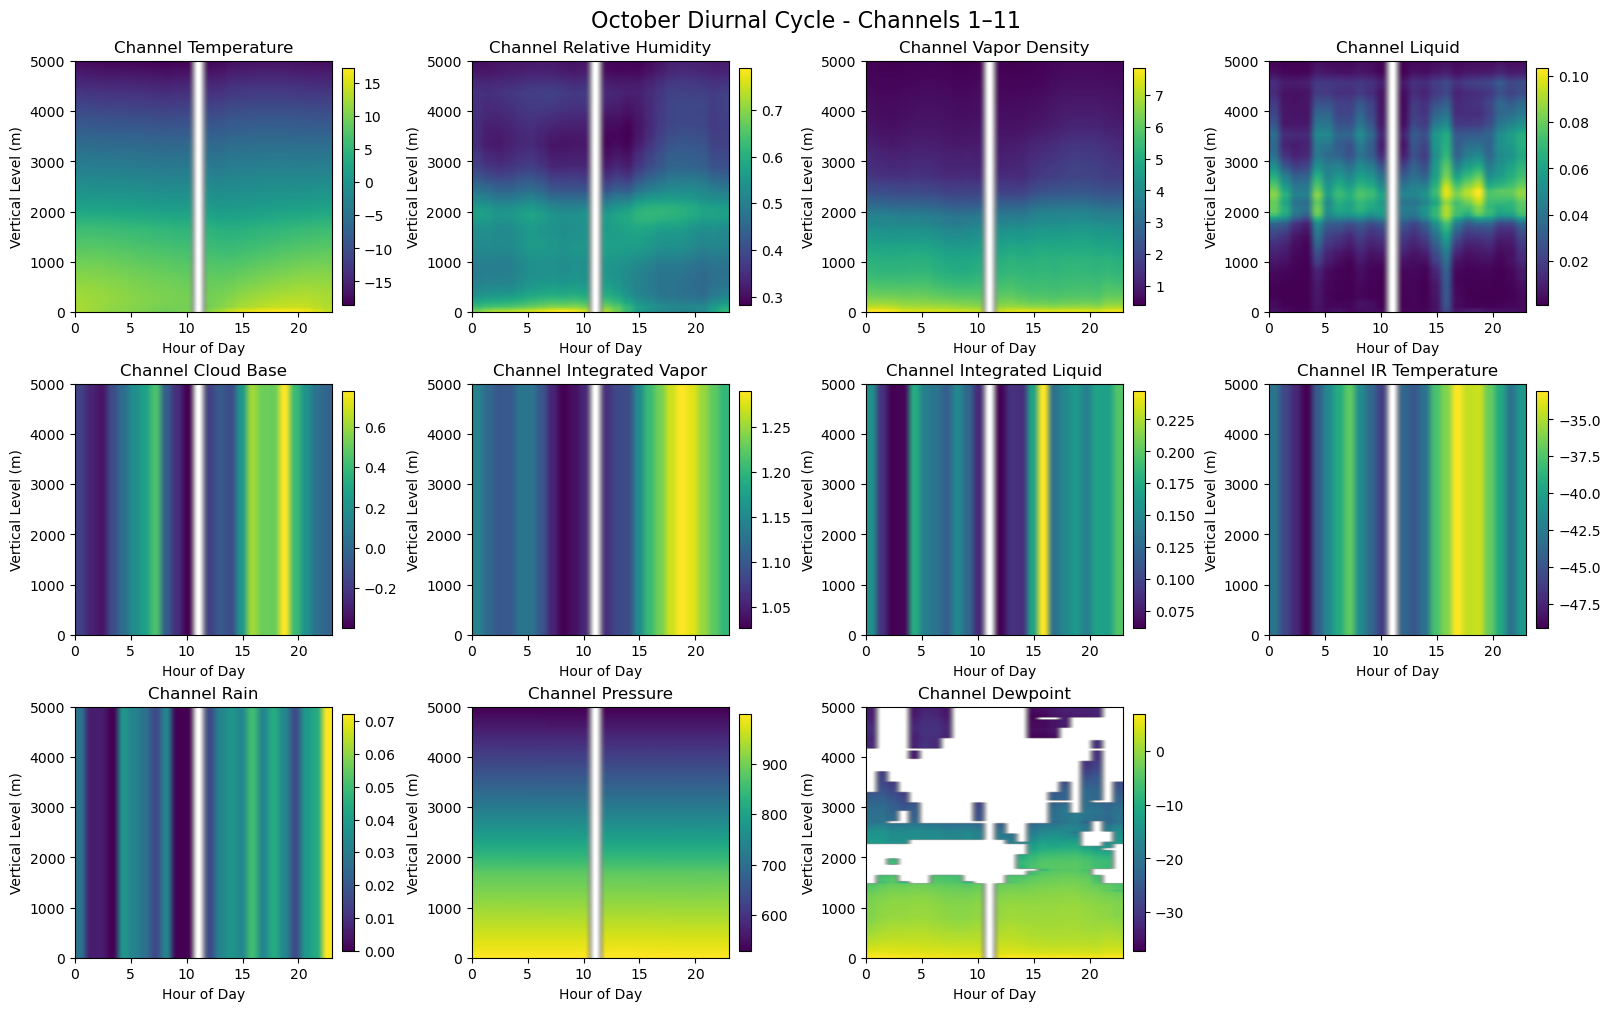

In [ ]:
# Extract November
octo = final_arr[9]  # (24, 121, 1, 11)
octo = octo.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = octo.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(octo.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        octo[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if octo.shape[2] < len(axes):
    for i in range(octo.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("October Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

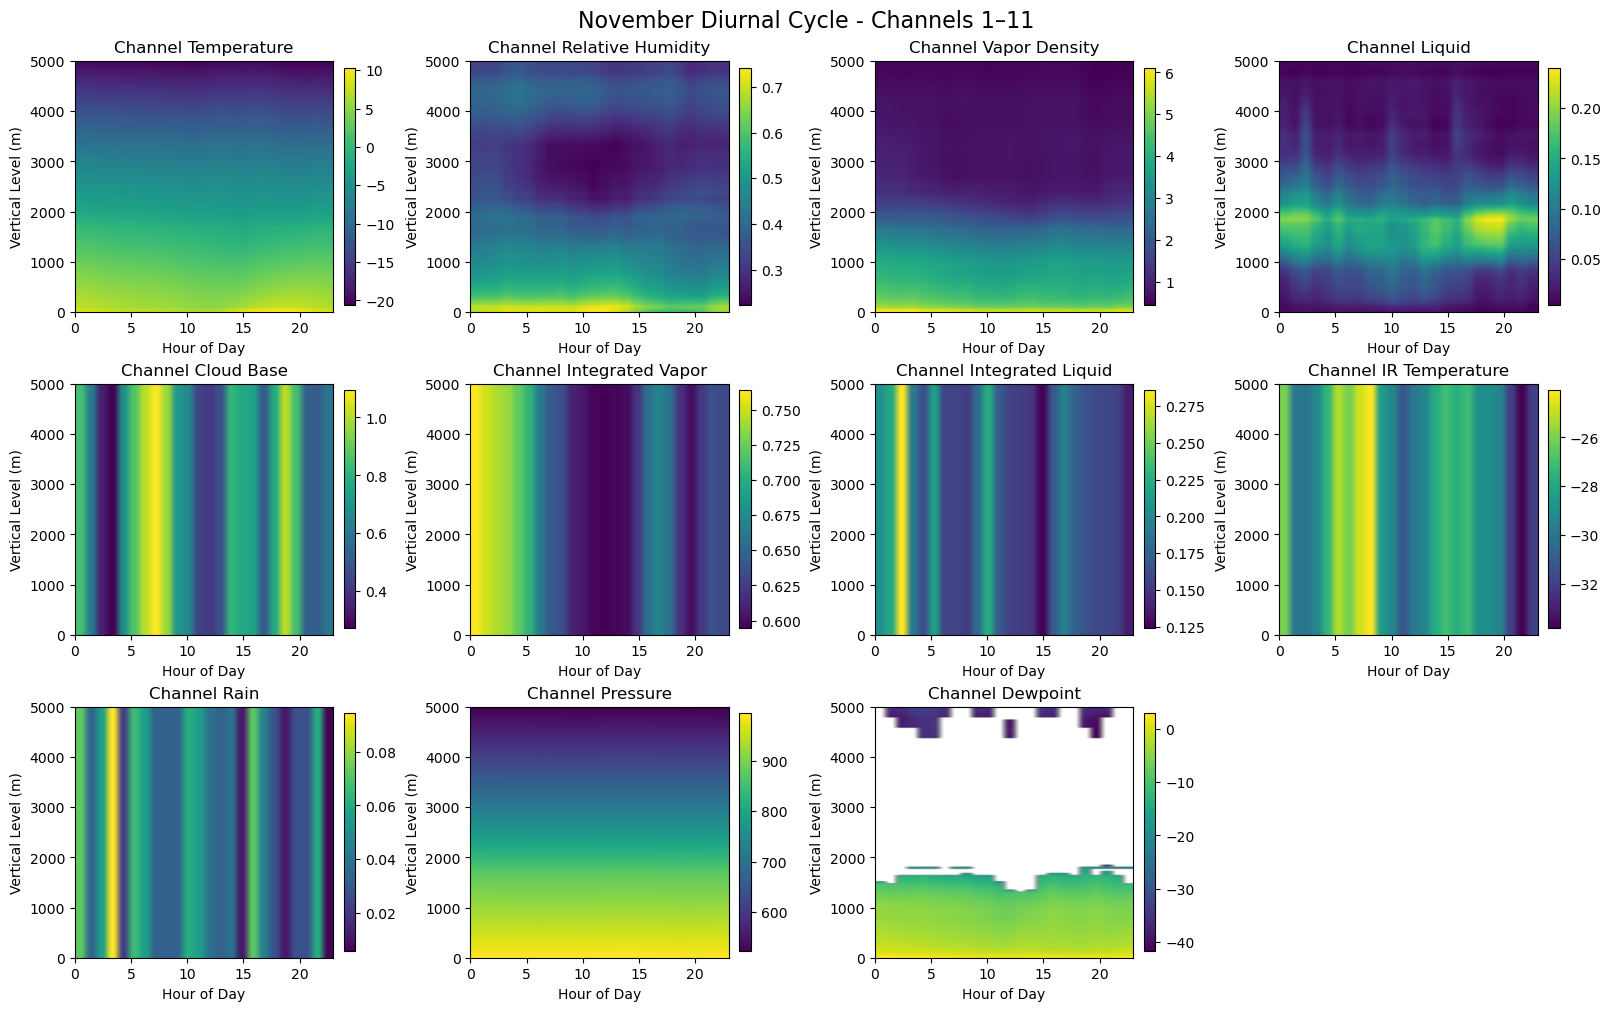

In [ ]:
# Extract November
nov = final_arr[10]  # (24, 121, 1, 11)
nov = nov.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = nov.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(nov.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        nov[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if nov.shape[2] < len(axes):
    for i in range(nov.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("November Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()

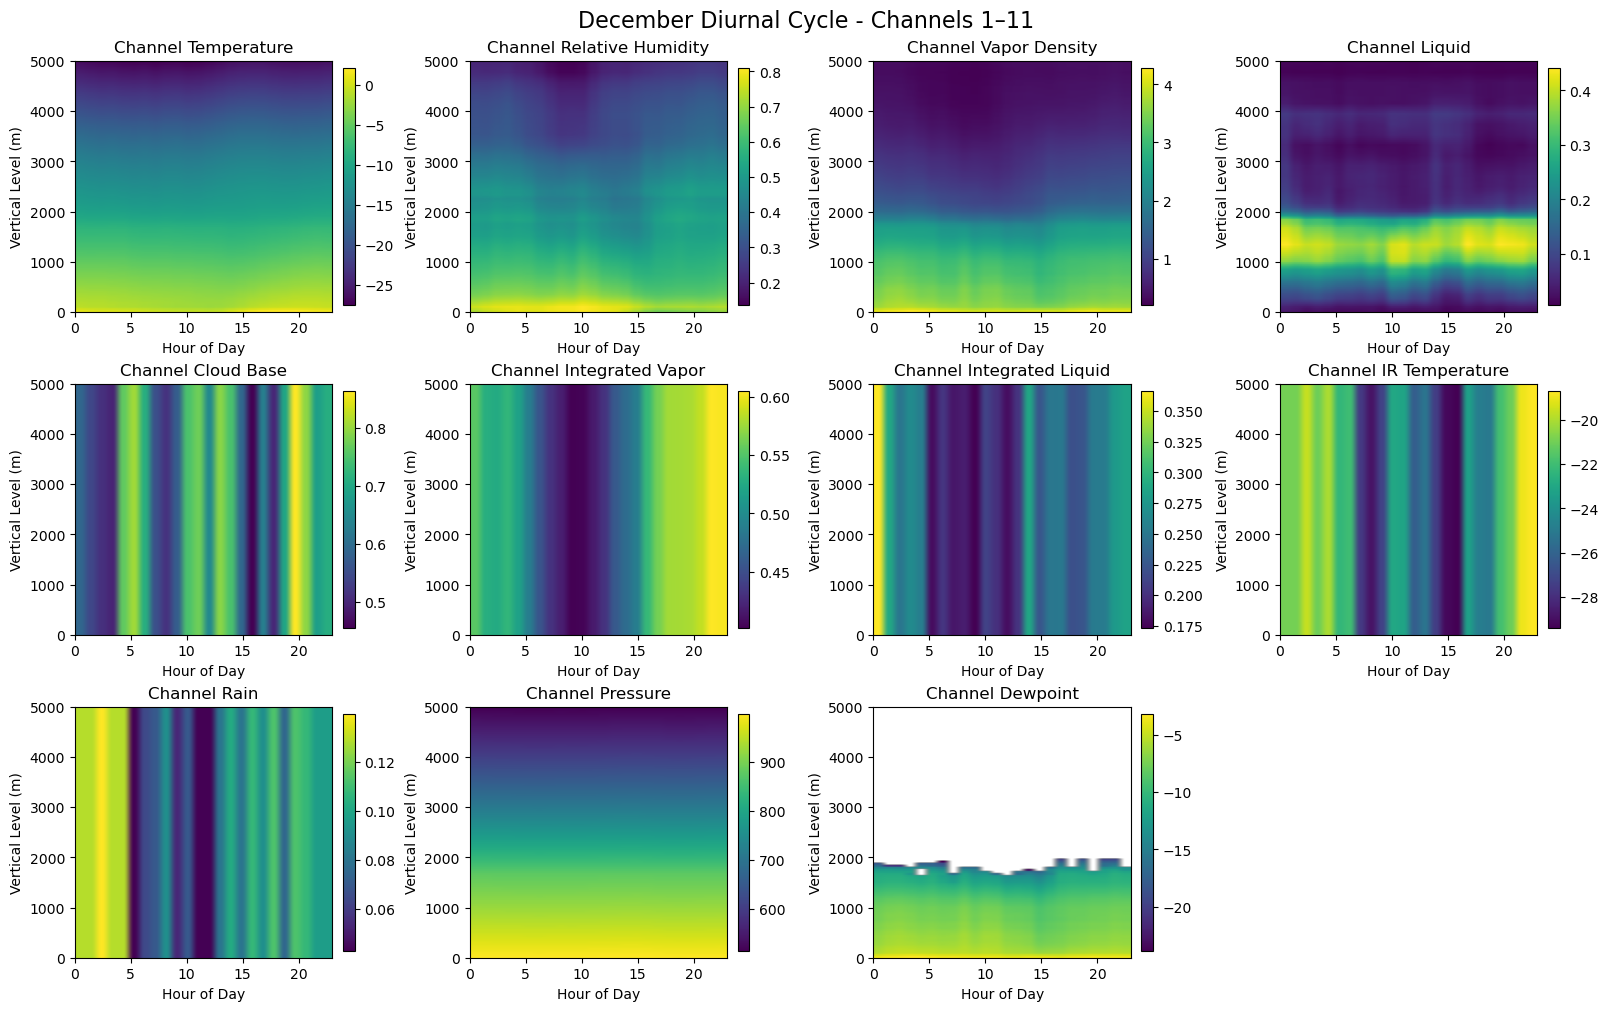

In [ ]:
# Extract December
dec = final_arr[11]  # (24, 121, 1, 11)
dec = dec.squeeze(axis=2)  # (24, 121, 11) -> (hours, vertical, channels)

n_vert = dec.shape[1]
vertical_levels = np.linspace(0, 5000, n_vert)  # 0 to 5000 m

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ch in range(dec.shape[2]):  # loop over channels
    # Transpose so vertical levels are y-axis, hours are x-axis
    im = axes[ch].imshow(
        dec[:, :, ch].T,  # shape (vertical, hours)
        aspect="auto",
        cmap="viridis",
        origin="lower",
        extent=[0, 23, vertical_levels[0], vertical_levels[-1]],
    )
    axes[ch].set_title(f"Channel {channels[ch]}")
    axes[ch].set_xlabel("Hour of Day")
    axes[ch].set_ylabel("Vertical Level (m)")
    fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

# Hide any unused subplot (since we have 11 channels, but 3x4=12 slots)
if dec.shape[2] < len(axes):
    for i in range(dec.shape[2], len(axes)):
        axes[i].axis("off")

plt.suptitle("December Diurnal Cycle - Channels 1–11", fontsize=16)
plt.show()